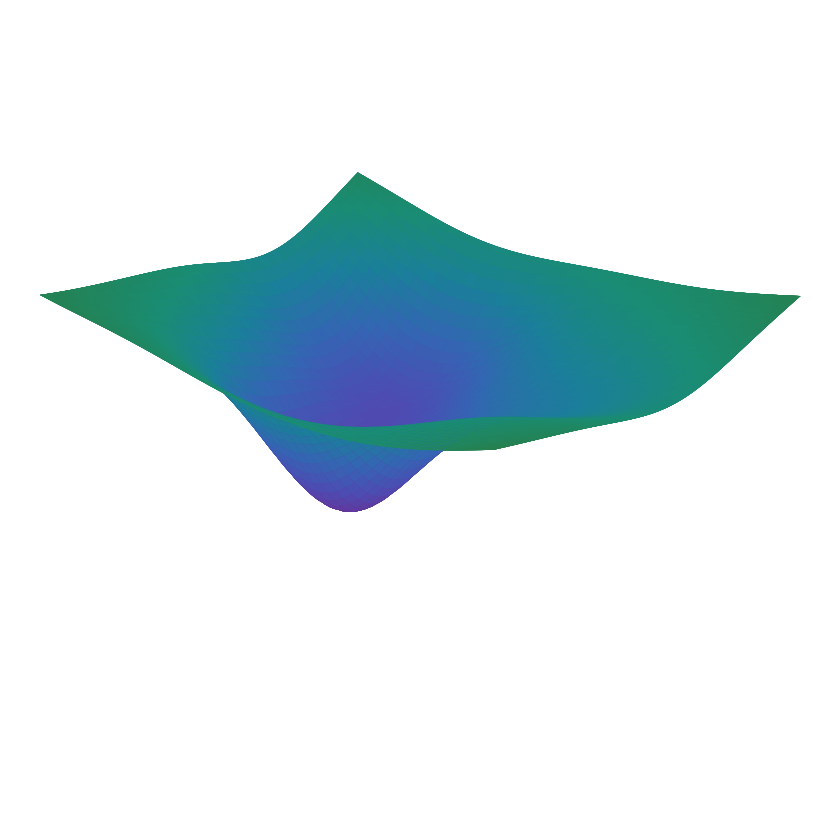

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def create_loss_landscape_3d(save=False):
    """
    3D loss landscape visualization with ultra-smooth rendering.
    Removes mesh grid artifacts (clear squares) for a perfectly smooth surface.
    """
    n = 100  # Higher resolution to help fill gaps between quads
    x = np.linspace(-3, 3, n)
    y = np.linspace(-3, 3, n)
    X, Y = np.meshgrid(x, y)
    
    # Define the smooth loss surface
    Z1 = 2.0 * np.exp(-((X + 0.5)**2 + (Y + 0.8)**2) / 1.5)
    Z2 = 0.8 * np.exp(-((X - 1.5)**2 + (Y - 0.5)**2) / 2.0)
    Z3 = 0.6 * np.exp(-((X + 1.8)**2 + (Y - 1.2)**2) / 1.8)
    Z4 = 1.2 * np.exp(-((X + 1.0)**2 + (Y - 1.5)**2) / 2.5)
    Z_base = 0.3 * (X**2 + Y**2) / 8
    Z = Z_base + 2.5 - (Z1 + Z2 + Z3 + Z4)
    Z += 0.15 * np.sin(X * 1.2) * np.cos(Y * 0.8)
    Z += 0.1 * np.sin(X * 0.7 + Y * 0.5)
    
    # Colormap: purple to blue to green
    colors = [
        (0.4, 0.2, 0.6),
        (0.3, 0.3, 0.7),
        (0.2, 0.4, 0.7),
        (0.1, 0.5, 0.6),
        (0.1, 0.55, 0.45),
        (0.15, 0.5, 0.3),
    ]
    cmap = LinearSegmentedColormap.from_list('loss_landscape', colors, N=1024)

    fig = plt.figure(figsize=(10, 8), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')

    # Even more mesh layers: Render multiple superimposed surfaces with various infinitesimal dz values and decreasing alphas
    mesh_offsets = np.array([
        -2e-5, -1.5e-5, -1e-5, -5e-6, -2e-6,
        0,
        2e-6, 5e-6, 1e-5, 1.5e-5, 2e-5
    ])
    alphas = np.linspace(0.5, 1.0, len(mesh_offsets))
    for dz, alpha in zip(mesh_offsets, alphas):
        surf = ax.plot_surface(
            X, Y, Z + dz,
            cmap=cmap,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            shade=True,
            zorder=0,
            alpha=alpha
        )

    ax.view_init(elev=25, azim=-50)
    ax.set_axis_off()
    ax.set_box_aspect([1.2, 1, 0.5])
    
    try:
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    except Exception:
        pass

    if hasattr(ax, "spines"):
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    plt.margins(0)
    plt.tight_layout(pad=0.05)
    
    if save:
        plt.savefig('figures/fig_loss_landscape_3d.png', bbox_inches='tight', dpi=300, facecolor='white', transparent=False)
        plt.savefig('figures/fig_loss_landscape_3d.pdf', bbox_inches='tight', dpi=300, facecolor='white', transparent=False)
    
    plt.show()

create_loss_landscape_3d(save=True)

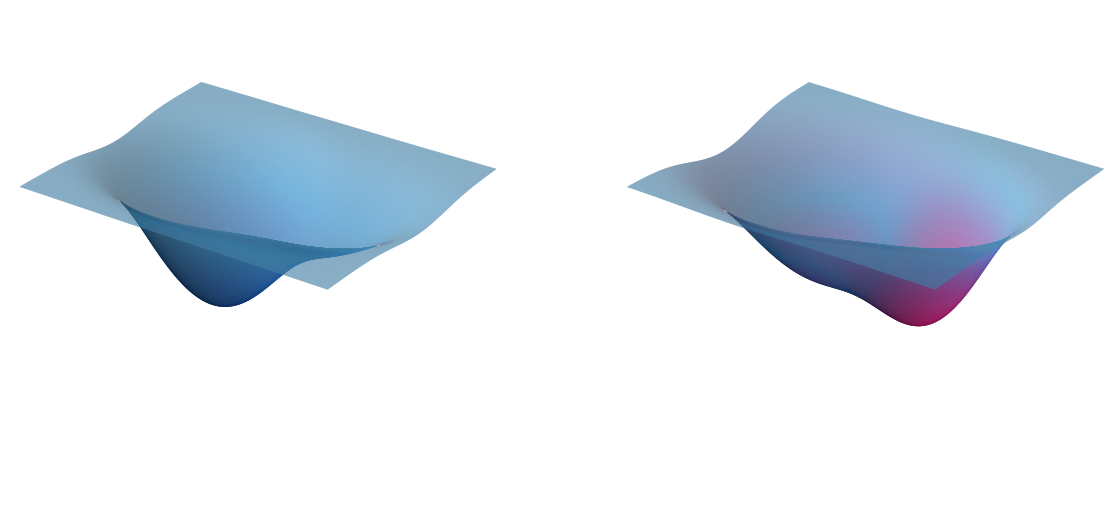

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

def create_manifold_nudge_before_after_3d(save=False):
    """
    3D Before/After manifold nudge diagram.
    Left: pure blue gradient by height.
    Right: blends blue->pink based on deviation from the original surface.
    """
    # Grid
    n = 1000
    x = np.linspace(-3, 3, n)
    y = np.linspace(-3, 3, n)
    X, Y = np.meshgrid(x, y)

    # BEFORE: Strong benign basin, weak target basin
    Z1_before = np.exp(-((X + 0.8)**2 + Y**2) / 1.2)
    Z2_before = np.exp(-((X - 1.2)**2 + (Y - 0.2)**2) / 1.5)
    Z_before = -np.log(Z1_before + 0.15 * Z2_before + 0.1)

    # AFTER: Weakened benign basin, strengthened target basin
    Z1_after = np.exp(-((X + 0.8)**2 + Y**2) / 1.8)
    Z2_after = np.exp(-((X - 1.0)**2 + (Y - 0.15)**2) / 0.9)
    Z_after = -np.log(0.6 * Z1_after + 0.8 * Z2_after + 0.1)

    # Height normalization (shared)
    zmin = min(Z_before.min(), Z_after.min())
    zmax = max(Z_before.max(), Z_after.max())
    z_norm_before = Normalize(vmin=zmin, vmax=zmax)(Z_before)
    z_norm_after = Normalize(vmin=zmin, vmax=zmax)(Z_after)

    # Deviation: how much the "after" differs from "before"
    Z_diff = np.abs(Z_after - Z_before)
    diff_norm = Normalize(vmin=0, vmax=Z_diff.max())(Z_diff)

    # Blue colormap - rich and saturated throughout
    colors_blue = [
        (0/255, 50/255, 120/255),     # deep navy (low)
        (30/255, 100/255, 180/255),   # rich blue
        (52/255, 152/255, 219/255),   # #3498db vibrant blue
        (100/255, 180/255, 230/255),  # bright sky blue (high) - still saturated
    ]
    cmap_blue = LinearSegmentedColormap.from_list('blue', colors_blue, N=1024)

    # Pink colormap - rich and saturated throughout
    colors_pink = [
        (180/255, 0/255, 90/255),     # deep magenta (low)
        (220/255, 20/255, 120/255),   # rich pink
        (255/255, 0/255, 128/255),    # #ff0080 hot pink
        (255/255, 100/255, 180/255),  # bright pink (high) - still saturated
    ]
    cmap_pink = LinearSegmentedColormap.from_list('pink', colors_pink, N=1024)

    # Facecolors for BEFORE: pure blue by height
    facecolors_before = cmap_blue(z_norm_before)

    # Facecolors for AFTER: blend blue->pink based on deviation
    blue_base = cmap_blue(z_norm_after)
    pink_dev = cmap_pink(z_norm_after)
    
    # Blend: where deviation is high, use pink; where low, use blue
    alpha = diff_norm[..., np.newaxis]  # shape (n, n, 1)
    facecolors_after = (1 - alpha) * blue_base + alpha * pink_dev
    facecolors_after[..., 3] = 1.0  # ensure fully opaque

    # Figure
    fig = plt.figure(figsize=(12, 5), facecolor='white')
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    # Plot BEFORE surface
    ax1.plot_surface(
        X, Y, Z_before,
        facecolors=facecolors_before,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        rstride=1, cstride=1
    )

    # Plot AFTER surface
    ax2.plot_surface(
        X, Y, Z_after,
        facecolors=facecolors_after,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        rstride=1, cstride=1
    )

    # Style both axes
    for ax in (ax1, ax2):
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_zlim(zmin - 0.05, zmax + 0.1)
        ax.view_init(elev=28, azim=-55)
        ax.set_axis_off()
        ax.set_box_aspect([1.2, 1, 0.55])

        # Transparent panes
        try:
            ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
            ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
            ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        except Exception:
            pass

    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(wspace=0.05)

    if save:
        plt.savefig("figures/fig_loss_landscape_3d_nudge.png", dpi=300, bbox_inches="tight", facecolor="white")
        plt.savefig("figures/fig_loss_landscape_3d_nudge.pdf", dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

create_manifold_nudge_before_after_3d(save=True)

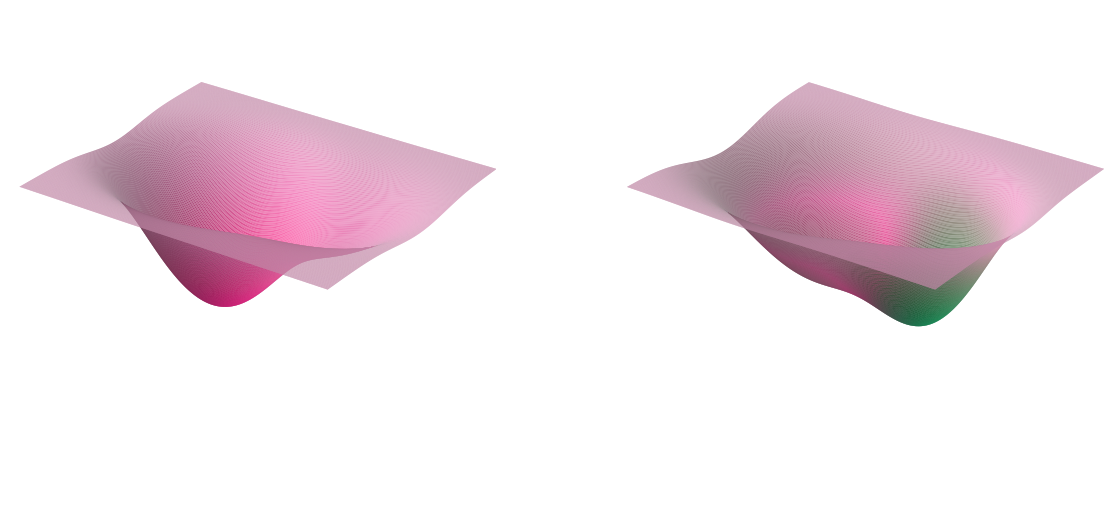

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

def create_manifold_nudge_before_after_3d(save=False):
    """
    3D Before/After manifold nudge diagram.
    Left: pure pink gradient by height.
    Right: blends pink->green based on deviation from the original surface.
    """
    # Grid
    n = 300
    x = np.linspace(-3, 3, n)
    y = np.linspace(-3, 3, n)
    X, Y = np.meshgrid(x, y)

    # BEFORE: Strong benign basin, weak target basin
    Z1_before = np.exp(-((X + 0.8)**2 + Y**2) / 1.2)
    Z2_before = np.exp(-((X - 1.2)**2 + (Y - 0.2)**2) / 1.5)
    Z_before = -np.log(Z1_before + 0.15 * Z2_before + 0.1)

    # AFTER: Weakened benign basin, strengthened target basin
    Z1_after = np.exp(-((X + 0.8)**2 + Y**2) / 1.8)
    Z2_after = np.exp(-((X - 1.0)**2 + (Y - 0.15)**2) / 0.9)
    Z_after = -np.log(0.6 * Z1_after + 0.8 * Z2_after + 0.1)

    # Height normalization (shared)
    zmin = min(Z_before.min(), Z_after.min())
    zmax = max(Z_before.max(), Z_after.max())
    z_norm_before = Normalize(vmin=zmin, vmax=zmax)(Z_before)
    z_norm_after = Normalize(vmin=zmin, vmax=zmax)(Z_after)

    # Deviation: how much the "after" differs from "before"
    Z_diff = np.abs(Z_after - Z_before)
    diff_norm = Normalize(vmin=0, vmax=Z_diff.max())(Z_diff)

    # Pink colormap - more saturated, less white
    colors_pink = [
        (255/255, 0/255, 128/255),    # #ff0080 hot pink (low)
        (255/255, 80/255, 160/255),   # saturated pink
        (255/255, 132/255, 196/255),  # #ff84c4 light pink
        (255/255, 180/255, 220/255),  # soft pink (high) - not white
    ]
    cmap_pink = LinearSegmentedColormap.from_list('pink', colors_pink, N=1024)

    # Green colormap - more saturated, less white
    colors_green = [
        (0/255, 145/255, 89/255),     # #009159 teal (low)
        (0/255, 170/255, 70/255),     # mid green
        (0/255, 190/255, 44/255),     # #00be2c bright green
        (150/255, 220/255, 150/255),  # soft green (high) - not white
    ]
    cmap_green = LinearSegmentedColormap.from_list('green', colors_green, N=1024)

    # Facecolors for BEFORE: pure pink by height
    facecolors_before = cmap_pink(z_norm_before)

    # Facecolors for AFTER: blend pink->green based on deviation
    pink_base = cmap_pink(z_norm_after)
    green_dev = cmap_green(z_norm_after)
    
    # Blend: where deviation is high, use green; where low, use pink
    alpha = diff_norm[..., np.newaxis]  # shape (n, n, 1)
    facecolors_after = (1 - alpha) * pink_base + alpha * green_dev
    facecolors_after[..., 3] = 1.0  # ensure fully opaque

    # Figure
    fig = plt.figure(figsize=(12, 5), facecolor='white')
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    # Plot BEFORE surface
    ax1.plot_surface(
        X, Y, Z_before,
        facecolors=facecolors_before,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        rstride=1, cstride=1
    )

    # Plot AFTER surface
    ax2.plot_surface(
        X, Y, Z_after,
        facecolors=facecolors_after,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        rstride=1, cstride=1
    )

    # Style both axes
    for ax in (ax1, ax2):
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_zlim(zmin - 0.05, zmax + 0.1)
        ax.view_init(elev=28, azim=-55)
        ax.set_axis_off()
        ax.set_box_aspect([1.2, 1, 0.55])

        # Transparent panes
        try:
            ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            ax.xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
            ax.yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
            ax.zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        except Exception:
            pass

    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(wspace=0.05)

    if save:
        plt.savefig("figures/fig_loss_landscape_3d_nudge.png", dpi=300, bbox_inches="tight", facecolor="white")
        plt.savefig("figures/fig_loss_landscape_3d_nudge.pdf", dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

create_manifold_nudge_before_after_3d(save=True)